H0^(-1) = 14.51 Gyr
Omega_L0 = 0.68491

Results:
Age of Universe today: t0 = 13.791 Gyr

Radiation-matter equality:
a_eq = 2.8571e-04
z_eq = 3499.0
t_eq = 4.8751e-05 Gyr = 48750.7 years

Matter-dark-energy equality, rho_m = rho_Lambda:
a = 0.7719
z = 0.296
t = 10.295 Gyr

Dark energy dominance, rho_Lambda = rho_m + rho_r:
a = 0.7720
z = 0.295
t = 10.296 Gyr

Onset of accelerated expansion, ddot(a) = 0:
a_acc = 0.6128
z_acc = 0.632
t_acc = 7.693 Gyr


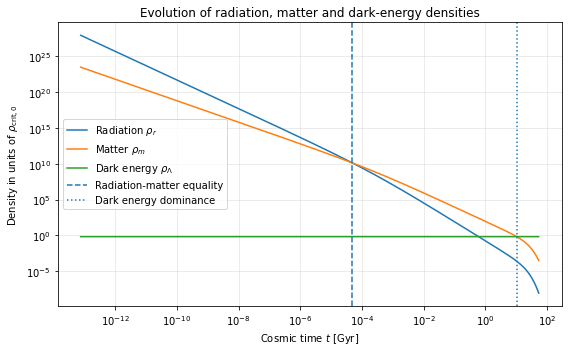

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import brentq

# -----------------------------
# Cosmological parameters
# -----------------------------

H0 = 67.4                 # km/s/Mpc
h = H0 / 100

# Hubble time in Gyr
H0_inv_Gyr = 9.778 / h
H0_Gyr = 1 / H0_inv_Gyr   # H0 in Gyr^{-1}

Omega_m0 = 0.315
Omega_r0 = 9.0e-5         # radiation today, approximate
Omega_L0 = 1.0 - Omega_m0 - Omega_r0  # flat universe

print(f"H0^(-1) = {H0_inv_Gyr:.2f} Gyr")
print(f"Omega_L0 = {Omega_L0:.5f}")


# Friedmann equation

def E(a):
    return np.sqrt(
        Omega_r0 * a**(-4)
        + Omega_m0 * a**(-3)
        + Omega_L0
    )

def H(a):
    #Hubble parameter in Gyr^{-1}
    return H0_Gyr * E(a)

def t_of_a(a):
    
    #t(a) = integral_0^a da' / (a' H(a'))
    integrand = lambda ap: 1.0 / (ap * H(ap))
    result, error = quad(integrand, 0, a, epsabs=1e-10, epsrel=1e-10)
    return result


# Energy densities normalized to today's critical density

def rho_r(a):
    return Omega_r0 * a**(-4)

def rho_m(a):
    return Omega_m0 * a**(-3)

def rho_L(a):
    return Omega_L0 * np.ones_like(a)



# Radiation-matter equality:
# rho_r = rho_m
a_rm_eq = Omega_r0 / Omega_m0
z_rm_eq = 1 / a_rm_eq - 1
t_rm_eq = t_of_a(a_rm_eq)

# Matter-dark-energy equality:
# rho_m = rho_Lambda
a_mL_eq = (Omega_m0 / Omega_L0)**(1/3)
z_mL_eq = 1 / a_mL_eq - 1
t_mL_eq = t_of_a(a_mL_eq)

# Dark energy dominance over all other components:
# rho_Lambda = rho_m + rho_r
def dominance_equation(a):
    return rho_L(np.array([a]))[0] - rho_m(a) - rho_r(a)

# Universe transitions to acceleration:
#ddot{a} = 0 =  rho_m + 2*rho_r - 2*rho_Lambda
def acceleration_transition_equation(a):
    return rho_m(a) + 2*rho_r(a) - 2*rho_L(np.array([a]))[0]

a_acc = brentq(acceleration_transition_equation, 1e-4, 2.0)
z_acc = 1 / a_acc - 1
t_acc = t_of_a(a_acc)


a_L_dom = brentq(dominance_equation, 1e-4, 2.0)
z_L_dom = 1 / a_L_dom - 1
t_L_dom = t_of_a(a_L_dom)

# Present age
t0 = t_of_a(1.0)

print("\nResults:")
print(f"Age of Universe today: t0 = {t0:.3f} Gyr")

print("\nRadiation-matter equality:")
print(f"a_eq = {a_rm_eq:.4e}")
print(f"z_eq = {z_rm_eq:.1f}")
print(f"t_eq = {t_rm_eq:.4e} Gyr = {t_rm_eq*1e9:.1f} years")

print("\nMatter-dark-energy equality, rho_m = rho_Lambda:")
print(f"a = {a_mL_eq:.4f}")
print(f"z = {z_mL_eq:.3f}")
print(f"t = {t_mL_eq:.3f} Gyr")

print("\nDark energy dominance, rho_Lambda = rho_m + rho_r:")
print(f"a = {a_L_dom:.4f}")
print(f"z = {z_L_dom:.3f}")
print(f"t = {t_L_dom:.3f} Gyr")

print("\nOnset of accelerated expansion, ddot(a) = 0:")
print(f"a_acc = {a_acc:.4f}")
print(f"z_acc = {z_acc:.3f}")
print(f"t_acc = {t_acc:.3f} Gyr")


# Plot densities as functions of time
a_values = np.logspace(-8, 1, 1200)

# Compute time for each scale factor
t_values = np.array([t_of_a(a) for a in a_values])

plt.figure(figsize=(8, 5))

plt.loglog(t_values, rho_r(a_values), label=r"Radiation $\rho_r$")
plt.loglog(t_values, rho_m(a_values), label=r"Matter $\rho_m$")
plt.loglog(t_values, rho_L(a_values), label=r"Dark energy $\rho_\Lambda$")

# Mark equality times
plt.axvline(t_rm_eq, linestyle="--", label="Radiation-matter equality")
plt.axvline(t_L_dom, linestyle=":", label="Dark energy dominance")

plt.xlabel(r"Cosmic time $t$ [Gyr]")
plt.ylabel(r"Density in units of $\rho_{\mathrm{crit},0}$")
plt.title("Evolution of radiation, matter and dark-energy densities")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()